In [8]:
# import library
import sys
import os
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import napari

from larch import Group
from larch.xafs import pre_edge


In [9]:
# Get the current directory 
current_dir = os.getcwd() if "__file__" not in globals() else os.path.dirname(os.path.abspath(__file__))

# Path to the module
stxm_napari_path = os.path.join(current_dir, "script", "STXM_napari")

# Add to sys.path
if stxm_napari_path not in sys.path:
    sys.path.append(stxm_napari_path)

from STXM_napari import (
    find_hdr_file,
    read_hdr,
    save_energy,
    load_tiff_stack,
    roi_manager,
    roi_plot,
    save_shapes_roi,
    normalize_roi_pre_edge,
    plot_roi_normalized,
    plot_napari_layers,
    add_scalebar,
    create_element_map
)

import STXM_napari
importlib.reload(STXM_napari)

<module 'STXM_napari' from 'c:\\Users\\Kouya\\Dropbox\\Research\\STXM_review\\napari\\STXMnapari-paper_scripts\\scripts\\STXM_napari.py'>

In [10]:
parent_dir = os.path.dirname(current_dir)
base_dir_c = os.path.join(parent_dir, "data", "20260307014")
data_dir_c = os.path.join(base_dir_c, "tiff")

print(data_dir_c)

c:\Users\Kouya\Dropbox\Research\STXM_review\napari\STXMnapari-paper_scripts\data\20260307014\tiff


In [ ]:
# read hdr file, analysis - PF BL-19A
hdr_file_c = find_hdr_file(base_dir_c)

# Read parameters 
xstep_c, ystep_c, energy_list_c = read_hdr(hdr_file_c)
print(f"XStep: {xstep_c}, YStep: {ystep_c}")

# Save energy information 
save_energy(energy_list_c, base_dir_c)
energy_file_c = os.path.join(base_dir_c, "energy.txt")

# Load TIFF image stack 
viewer_c, energies_c, image_stack_c = load_tiff_stack(data_dir_c, energy_file_c, xstep_c, ystep_c) 
c_map=create_element_map(viewer_c, image_stack_c,xstep_c,ystep_c,element="C", 
                  pre_range=(280, 284), post_range=(290, 300))

# ROI management
shapes_layer_c, points_layer_c = roi_manager(viewer_c, xstep_c)
roi_info_c = roi_plot(viewer_c, shapes_layer_c, image_stack_c, energies_c)

# Set the viewer theme
viewer_c.theme = 'light'

XStep: 0.05, YStep: 0.05
Energy list saved to c:\Users\Kouya\Dropbox\Research\STXM_review\napari\STXMnapari-paper_scripts\data\20260307014\energy.txt
id, eV


WARNING [2026-05-19 15:19:40]: QWindowsWindow::setGeometry: Unable to set geometry 2172x1318+1472+165 (frame: 2194x1374+1461+120) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 3260x1165+1475+179 (frame: 3282x1221+1464+134) margins: 11, 45, 11, 11 minimum size: 385x487 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=792,1030 maxtrack=0,0)


<Figure size 300x300 with 0 Axes>


Current ROI Data:

Current ROI Data:
ROI a: [[24.31579   12.043857 ]
 [28.192984   7.9385934]
 [36.63158    7.710523 ]
 [43.017544  17.745611 ]
 [35.94737   22.307014 ]
 [25.228071  19.114033 ]
 [24.08772   15.92105  ]]
  中心: [31.060152 14.682955]
ROI b: [[ 8.807018 79.32456 ]
 [10.175439 67.69298 ]
 [14.736843 61.535084]
 [24.08772  78.18421 ]
 [17.245615 87.307014]
 [10.175439 85.02631 ]]
  中心: [14.204679 76.511696]
ROI c: [[48.035088 65.41228 ]
 [53.508774 56.0614  ]
 [62.85965  57.657894]
 [71.98246  59.938595]
 [80.42105  72.02631 ]
 [67.649124 75.67544 ]
 [50.315792 71.3421  ]]
  中心: [62.11027 65.44486]
Successfully loaded 3 ROIs.
ROI update
   Energy  Mean Intensity ROI
0   280.0        0.535191   a
1   280.5        0.529923   a
2   281.0        0.526402   a
3   281.5        0.525222   a
4   282.0        0.535562   a


In [ ]:
# Create a directory for saving ROI data (e.g., base_dir/napari_roi_data)
save_roi_dir = os.path.join(base_dir_c, 'napari_roi_data')
os.makedirs(save_roi_dir, exist_ok=True)

basename = f"20260307014_roi"

# Export ROI data 
# saved_paths = save_shapes_roi(shapes_layer_c, save_roi_dir, basename)

# Display the destination path of the saved file
# print(f"Saved ROI data to: {saved_paths}")

Saved ROI data to: c:\Users\Kouya\Dropbox\Research\STXM_review\napari\STXMnapari-paper_scripts\data\20260307014\napari_roi_data\20260307014_roi.npz


In [14]:
# ROI Normalization
normalize_roi_df = normalize_roi_pre_edge(roi_info_c['roi_df'], 
                                          e0=284, 
                                          pre1=-4, 
                                          pre2=0, 
                                          norm1=8, 
                                          norm2=16,
                                          nnorm=1,
                                          pre_post_line=True)

print(normalize_roi_df)

# Create the output directory for ROI data
save_roi_dir = os.path.join(base_dir_c, 'napari_roi_data')
os.makedirs(save_roi_dir, exist_ok=True)

# Output filename
basename = f"20260307014_roi_normalize.csv"
save_path = os.path.join(save_roi_dir, basename)

# save
normalize_roi_df.to_csv(save_path, index=False)

print(f"Saved ROI data to: {save_path}")

     Energy  Mean Intensity ROI  Normalized Mean Intensity  pre_edge_line  \
0     280.0        0.535191   a                   0.006159       0.533420   
1     280.5        0.529923   a                  -0.007233       0.532002   
2     281.0        0.526402   a                  -0.014548       0.530585   
3     281.5        0.525222   a                  -0.013723       0.529167   
4     282.0        0.535562   a                   0.027173       0.527750   
..      ...             ...  ..                        ...            ...   
298   298.0        0.378879   c                   1.044284       0.163296   
299   298.5        0.370821   c                   1.011196       0.162489   
300   299.0        0.366245   c                   0.994496       0.161683   
301   299.5        0.385674   c                   1.090807       0.160877   
302   300.0        0.386307   c                   1.098632       0.160070   

     post_edge_line        mu  
0          0.836943  0.535191  
1          

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Energy (eV)')

Text(0, 0.5, 'Intensity')

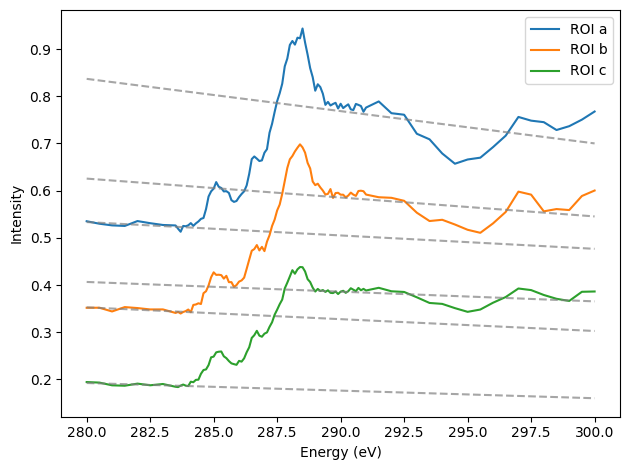

In [15]:
# check normalization
# Create a figure
plt.figure()

for roi_name, group in normalize_roi_df.groupby('ROI'):
    group = group.sort_values('Energy')
    
    # Plot raw experimental data 
    plt.plot(group['Energy'], group['Mean Intensity'], label=f'ROI {roi_name}')
    
    # Overlay the pre-edge and post-edge lines
    if 'pre_edge_line' in group.columns:
        plt.plot(group['Energy'], group['pre_edge_line'], '--', color='gray', alpha=0.7)
        plt.plot(group['Energy'], group['post_edge_line'], '--', color='gray', alpha=0.7)

# Labeling the axes
plt.xlabel('Energy (eV)')
plt.ylabel('Intensity')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 400x400 with 0 Axes>

Text(0.5, 1.0, '')

Text(0.5, 0, 'Energy (eV)')

Text(0, 0.5, 'Absorbance')

([], [])

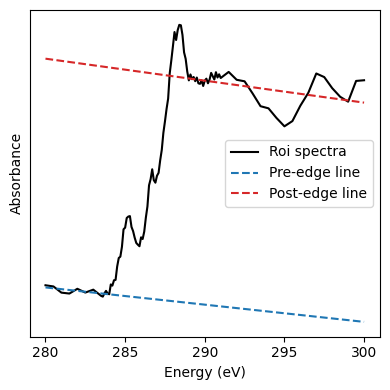

In [17]:
# Plot pre-edge and post-edge lines for the third ROI
third_roi = normalize_roi_df['ROI'].unique()[2]
roi_data = normalize_roi_df[normalize_roi_df['ROI'] == third_roi]
energy = roi_data['Energy']

plt.figure(figsize=(4,4))
plt.plot(energy, roi_data['Mean Intensity'], label='Roi spectra', color='black')

plt.plot(energy, roi_data['pre_edge_line'], label='Pre-edge line', color='#1f77b4', linestyle='--')
plt.plot(energy, roi_data['post_edge_line'], label='Post-edge line', color='#d62728', linestyle='--')

plt.title(f'')
plt.xlabel('Energy (eV)')
plt.ylabel('Absorbance')
plt.yticks([])
plt.legend()
plt.tight_layout()


# directory
save_fig_dir = os.path.join(base_dir_c, 'napari_analysis')
os.makedirs(save_fig_dir, exist_ok=True)

# path
save_fig_path = os.path.join(save_fig_dir, 'ROI3_spectra.png')
plt.savefig(save_fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# cut 282.0 to 294.0 eV
df_filtered = normalize_roi_df[(normalize_roi_df['Energy'] >= 282.0) & 
                               (normalize_roi_df['Energy'] <= 294.0)]

# directory
save_fig_dir = os.path.join(base_dir_c, 'napari_analysis')
os.makedirs(save_fig_dir, exist_ok=True)

# path
save_fig_path = os.path.join(save_fig_dir, 'roi_normalize_spectrum.png')

# ROI Figure 
save_fig = plot_roi_normalized(df_filtered,
                               label_step = 2,
                               figsize=(4, 3),
                               text_size=15,
                               y_margin=0.2)
save_fig.show()

# save
save_fig.savefig(save_fig_path, dpi=300, bbox_inches='tight')
plt.close(save_fig)

print(f"Figure successfully saved to: {save_fig_path}")

Figure successfully saved to: c:\Users\Kouya\Dropbox\Research\STXM_review\napari\STXMnapari-paper_scripts\data\20260307014\napari_analysis\roi_normalize_spectrum.png


(np.float64(0.0), np.float64(6.5), np.float64(4.5), np.float64(0.0))

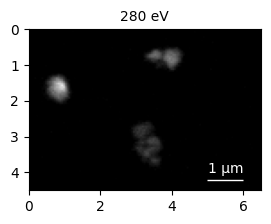

In [19]:
# Scale Bar Calibration Check
# 280 eV
energies_c_array = np.array(energies_c)       
energy_index_280 = np.argmin(np.abs(energies_c_array - 280.0))

# Extract the image at 280 eV
img_280eV = image_stack_c[energy_index_280, :, :]

# Plot the image 
fig, ax = plot_napari_layers(img_280eV, 
                             xstep=xstep_c,
                             ystep=ystep_c,
                             image_stack_max=image_stack_c,
                             shapes_layer=None, 
                             points_layer=None,
                             fontsize=10,
                             unit="μm",
                             title="280 eV",
                             cmap='gray', 
                             vmin=0.05, # OD >= 0.05
                             figsize=(3,3))

# Add a scale bar
# Adjust these parameters to fit image scale
add_scalebar(ax, xstep_c, length_um=1, color='white',
             height_um=0.01, fontsize=10, pad_um=0.5, unit='μm', bar_x=5, bar_y=4.2)
ax.axis("on")

# Note: Adjust parameter 

In [ ]:
# Figure parameters
vmin = 0.05        # minimum value of the OD image; values below this are displayed in black
pad_um = 0.5       # padding of scale bar
unit = 'μm'        # unit label for the scale bar
bar_x = 5          # x-coordinate of the scale bar
bar_y = 4.2        # y-coordinate of the scale bar
length_um = 1      # scale bar length [μm]
figsize = (3, 3)   # figure size (width, height)

In [ ]:
#  output directory
save_fig_dir = os.path.join(base_dir_c, 'napari_analysis')
os.makedirs(save_fig_dir, exist_ok=True)

energies_c_array = np.array(energies_c)

# 1. Pre-edge Image (280 eV)
energy_index_280 = np.argmin(np.abs(energies_c_array - 280.0))
img_280eV = image_stack_c[energy_index_280, :, :]
fig, ax = plot_napari_layers(img_280eV, xstep=xstep_c, ystep=ystep_c, image_stack_max=image_stack_c,
                             shapes_layer=None, points_layer=None, fontsize=10, fontsize_label=10,  
                             unit="μm", title="280 eV", cmap='gray', vmin=vmin, figsize=figsize)

add_scalebar(ax, xstep_c, length_um=length_um, color='white',
             height_um=0.01, fontsize=10, pad_um=pad_um, unit='μm', bar_x=bar_x, bar_y=bar_y)

save_path = os.path.join(save_fig_dir, '280.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close(fig)


# 2. Post-edge Image (300 eV)
energy_index_300 = np.argmin(np.abs(energies_c_array - 300.0))
img_300eV = image_stack_c[energy_index_300, :, :]
fig, ax = plot_napari_layers(img_300eV, xstep=xstep_c, ystep=ystep_c, image_stack_max=image_stack_c,
                             shapes_layer=None, points_layer=None, fontsize=10, fontsize_label=10,  
                             unit="μm", title="300 eV", cmap='gray', vmin=vmin, figsize=figsize)

add_scalebar(ax, xstep_c, length_um=length_um, color='white',
             height_um=0.01, fontsize=10, pad_um=pad_um, unit='μm', bar_x=bar_x, bar_y=bar_y)

save_path = os.path.join(save_fig_dir, '300.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close(fig)


# 3. Carbon Map
fig, ax = plot_napari_layers(c_map, xstep=xstep_c, ystep=ystep_c,
                             shapes_layer=None, points_layer=None, fontsize=10, fontsize_label=10,  
                             unit="μm", title="C map", cmap='gray', vmin=vmin, figsize=figsize)

add_scalebar(ax, xstep_c, length_um=length_um, color='white',
             height_um=0.01, fontsize=10, pad_um=pad_um, unit='μm', bar_x=bar_x, bar_y=bar_y)

save_path = os.path.join(save_fig_dir, 'Cmap.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close(fig)


# 4. Post-edge Image with ROI Overlays
energy_index_300 = np.argmin(np.abs(energies_c_array - 300.0))
img_300eV = image_stack_c[energy_index_300, :, :]
fig, ax = plot_napari_layers(img_300eV, xstep=xstep_c, ystep=ystep_c, image_stack_max=image_stack_c,
                             shapes_layer=shapes_layer_c, points_layer=points_layer_c, fontsize=10, fontsize_label=10,  
                             unit="μm", title="ROI (300 eV)", cmap='gray', vmin=vmin, figsize=figsize)

add_scalebar(ax, xstep_c, length_um=length_um, color='white',
             height_um=0.01, fontsize=10, pad_um=pad_um, unit='μm', bar_x=bar_x, bar_y=bar_y)

save_path = os.path.join(save_fig_dir, '300_roi.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close(fig)


# 5. Carbon Map with ROI Overlays
fig, ax = plot_napari_layers(c_map, xstep=xstep_c, ystep=ystep_c,
                             shapes_layer=shapes_layer_c, points_layer=points_layer_c, fontsize=10, fontsize_label=10,  
                             unit="μm", title="ROI (C map)", cmap='gray', vmin=vmin, figsize=figsize)

add_scalebar(ax, xstep_c, length_um=length_um, color='white',
             height_um=0.01, fontsize=10, pad_um=pad_um, unit='μm', bar_x=bar_x, bar_y=bar_y)

save_path = os.path.join(save_fig_dir, 'Cmap_roi.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close(fig)




Current ROI Data:
ROI a: [[24.31579   12.043857 ]
 [28.192984   7.9385934]
 [36.63158    7.710523 ]
 [43.017544  17.745611 ]
 [35.94737   22.307014 ]
 [25.228071  19.114033 ]
 [24.08772   15.92105  ]]
  中心: [31.060152 14.682955]
ROI b: [[ 8.807018 79.32456 ]
 [10.175439 67.69298 ]
 [14.736843 61.535084]
 [24.08772  78.18421 ]
 [17.245615 87.307014]
 [10.175439 85.02631 ]]
  中心: [14.204679 76.511696]
ROI c: [[48.035088 65.41228 ]
 [53.508774 56.0614  ]
 [62.85965  57.657894]
 [71.98246  59.938595]
 [80.42105  72.02631 ]
 [67.649124 75.67544 ]
 [50.315792 71.3421  ]]
  中心: [62.11027 65.44486]
